In [1]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
n_community = 2
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [3]:
def compute_geodesic(polytope_id1, polytope_id2):

    total_layers = len(polytope_id1)
    w = 1.0

    for ii in range(total_layers):
        w_ = 1-np.array(dist( polytope_id1[ii], polytope_id2[ii], 'hamming'))
        w = w*w_
           
    return 1-w[0][0]

In [101]:
class RNN_main(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super(RNN_main, self).__init__()
        # self.cortex_hidden = torch.zeros(1, 1, hidden_size_cortex)
        
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, nonlinearity='relu', batch_first=True)  
        self.fc = nn.Linear(hidden_size, len(tokens))
        
    def forward(self, x, h0=None, activation=False):           
        if h0 == None:
            out, h0 = self.rnn(x)
        else:   
            out, h0 = self.rnn(x, h0)
            
        out_ = self.fc(out)

        if activation:
            id = []

            for ii in range(len(h0)):
                id.append(np.array(h0[ii]>0))

            # print(out_)
            # max_val = torch.max(out_)
            id.append(np.array(out_>=0)[0])

            return id, h0

        return out_[:,-1,:], h0

In [102]:
class Dataset_converter_(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [103]:
### initial training ###
total_samples = 30000
working_memory = 1
short_term_memory = 1
hidden_size = 4000
num_layers = 2
lr = 5e-4
test_acc = []

    
data = get_sequence(total_samples, n_community, n_members, random_state=0)
data_test = get_sequence(total_samples, n_community, n_members, random_state=0)
data_set = Dataset_converter_(data, working_memory, short_term_memory)
data_set_test = Dataset_converter_(data_test, working_memory, short_term_memory)

main_model = RNN_main(len(tokens)*working_memory, hidden_size, num_layers)

train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
test_loader = DataLoader(data_set_test, batch_size=1, shuffle=False) 

optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
for (X, y), (X_test, y_test) in zip(train_loader, test_loader):
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = main_model(X)
    else:
        predicted_y, hidden = main_model(X, mem)
        
    loss = criterion(predicted_y, y)
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem = hidden.clone()
        
        if total == 0:
            predicted_y, hidden_ = main_model(X_test)
        else:
            predicted_y, hidden_ = main_model(X_test, hidden_)

        
        true_y = y_test.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')



Iter : 1001, loss: 2.0621, accuracy: 0.1930
Iter : 2001, loss: 2.3700, accuracy: 0.2870
Iter : 3001, loss: 1.3050, accuracy: 0.4490
Iter : 4001, loss: 1.5289, accuracy: 0.6940
Iter : 5001, loss: 2.6103, accuracy: 0.7210
Iter : 6001, loss: 2.7815, accuracy: 0.7540
Iter : 7001, loss: 1.2343, accuracy: 0.7510
Iter : 8001, loss: 1.3415, accuracy: 0.7530
Iter : 9001, loss: 1.7288, accuracy: 0.7640
Iter : 10001, loss: 1.9464, accuracy: 0.7670
Iter : 11001, loss: 1.3341, accuracy: 0.7620
Iter : 12001, loss: 1.7584, accuracy: 0.7620
Iter : 13001, loss: 1.2810, accuracy: 0.7520
Iter : 14001, loss: 1.6743, accuracy: 0.7520
Iter : 15001, loss: 1.0163, accuracy: 0.7470
Iter : 16001, loss: 1.2864, accuracy: 0.7470
Iter : 17001, loss: 1.7758, accuracy: 0.7540
Iter : 18001, loss: 1.6302, accuracy: 0.7480
Iter : 19001, loss: 1.3429, accuracy: 0.7470
Iter : 20001, loss: 1.4637, accuracy: 0.7510
Iter : 21001, loss: 1.7978, accuracy: 0.7610
Iter : 22001, loss: 1.8149, accuracy: 0.7520
Iter : 23001, loss:

In [104]:
data = get_sequence(1000, n_community, n_members, random_state=0)

data_set = Dataset_converter_(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 

ii = 0
dis = [0]
# cummulative_id = list(range(1))
community = ''
for X, _ in train_loader:
    if ii==0:
        id, h0 = main_model(X, activation=True)
        # cummulative_id.append(id)
        id_current = id.copy()
        # community = tokens[torch.argmax(X[0])]
    else:
        id, h0 = main_model(X, h0, activation=True)

        id_current = id.copy()
        if ii>=1:
            dis.append(compute_geodesic(id_current, prev_id))
            # print(dis)
            if dis[-1] >0.53621305:
                # print(dis, tokens[torch.argmax(X[0])])
                community += tokens[torch.argmax(X[0])]
                
        
    prev_id = id.copy()
    ii += 1

    # if ii==2000:
    #     break

# print(community)

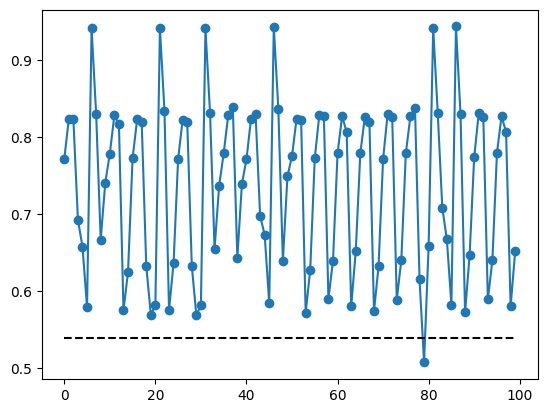

In [105]:
span = 100
plt.plot(dis[-span:], '-o')
plt.plot(np.arange(span), [.54]*span, '--', c='k')

In [106]:
dis_array = np.array(dis)
threshold = np.quantile(dis_array, .55)

mask = ((dis_array>threshold)*1)

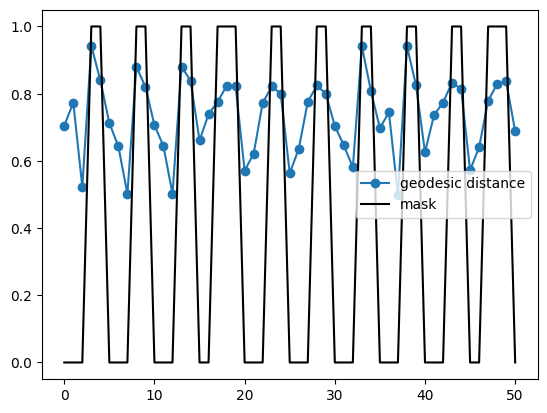

In [107]:
span = 51
plt.plot(dis[1:span+1], '-o', label='geodesic distance')
plt.plot(mask[1:span+1], c='k', label = 'mask')
plt.legend()

In [108]:
community[:500]

'CAGEFDGEFDGBACBGDEFDGDEFDGDFEDGDFEGEDFEGEDFEGDFDGBACBGABCAGDFEDGBCBGABCAGBACBGACBAGBACBGDFEDGABCAGDEFDGDEFDGBACBGBCABGEDFEGDEFDGEDFEGDFDGBACBGDEFDGABCAGDEFDGABCAGEFDGEFDGBACBGDEFDGEFDGACBAGABCAGEDFEGBCABGEFDGDEFDGEDFEGEDFEGDFDGBACBGDEFDGBCABGEFDGDEFDGDFEDGEDFEGBACBGDEFDGBCABGBCABGEDFEGEFDGBACBGEFDGABCAGDEFDGBCABGABCAGBACBGACBAGACBAGEDFEGEFDGBACBGBCABGBACBGDFEDGEFDGBACBGEFDGABCAGABCAGEDFEGBCABGDEFDGEFDGEDFEGEDFEGDFDGDFEGACBAGEFDGDEFDGACBAGABCAGDFEDGABCAGABCAGEDFEGEFDGBACBGDEFDGABCAGBCBGEDFEGBCABG'

In [109]:
mask[:200]

array([0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 1])

In [110]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super(RNN, self).__init__()
        self.cortex_hidden = torch.zeros(1, 1, hidden_size)
        
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, nonlinearity='relu', batch_first=True)  
        # self.fc_mask1 = nn.Linear(hidden_size, 10)
        self.fc = nn.Linear(hidden_size, 2)
        
    def forward(self, x, h0=None):           
        if h0 == None:
            out, h0 = self.rnn(x)
        else:   
            out, h0 = self.rnn(x, h0)
            
        out_ = self.fc(out)

        return out_, h0

In [111]:
class Dataset_converter(Dataset):
    def __init__(self, data, mask):
        total_sample = len(data)
        self.X = np.zeros((total_sample-2, len(tokens)))
        self.y = np.zeros((total_sample-2, 2))
        for ii, token in enumerate(data[:-2]):
            self.X[ii, ord(token)-65] = 1 
            self.y[ii,mask[ii]] = 1
            

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [112]:
class Dataset_converter_test(Dataset):
    def __init__(self, data):
        total_sample = len(data)
        self.X = np.zeros((total_sample-2, len(tokens)))
        for ii, token in enumerate(data[:-2]):
            self.X[ii, ord(token)-65] = 1 
            

        self.X = tnsr(self.X).float()

    def __getitem__(self, index):
        return self.X[index]

    def __len__(self):
        return self.X.shape[0]

In [113]:
test_acc = []
compression = []
compression_model = RNN(len(tokens), 10, 1)

data_set = Dataset_converter(data, mask)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 

optimizer = torch.optim.SGD(compression_model.parameters(), lr=4e-3, momentum=0.95)
criterion = torch.nn.MSELoss()

total = 0
correct = np.zeros(1000, dtype=float)
for X, y in train_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = compression_model(X)
    else:
        predicted_y, hidden = compression_model(X, mem)
        
    loss = criterion(predicted_y, y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        mem = hidden.clone()

        # if total<8:
        #     print(X)
        # print(y, predicted_y)
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        if estimated_y[0]:
            compression.append((true_y[0],estimated_y[0],tokens[X.argmax(axis=1)]))
            
        total += 1
        if true_y == estimated_y:
            correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')



In [114]:
compression[-200:]

[(tensor(1), tensor(1), 'G'),
 (tensor(1), tensor(1), 'B'),
 (tensor(1), tensor(1), 'G'),
 (tensor(1), tensor(1), 'D'),
 (tensor(1), tensor(1), 'G'),
 (tensor(1), tensor(1), 'E'),
 (tensor(1), tensor(1), 'G'),
 (tensor(1), tensor(1), 'A'),
 (tensor(0), tensor(1), 'A'),
 (tensor(1), tensor(1), 'G'),
 (tensor(1), tensor(1), 'E'),
 (tensor(1), tensor(1), 'G'),
 (tensor(1), tensor(1), 'B'),
 (tensor(1), tensor(1), 'G'),
 (tensor(1), tensor(1), 'B'),
 (tensor(1), tensor(1), 'G'),
 (tensor(1), tensor(1), 'A'),
 (tensor(1), tensor(1), 'G'),
 (tensor(1), tensor(1), 'B'),
 (tensor(1), tensor(1), 'G'),
 (tensor(1), tensor(1), 'A'),
 (tensor(1), tensor(1), 'G'),
 (tensor(1), tensor(1), 'D'),
 (tensor(1), tensor(1), 'G'),
 (tensor(1), tensor(1), 'B'),
 (tensor(1), tensor(1), 'G'),
 (tensor(1), tensor(1), 'D'),
 (tensor(1), tensor(1), 'G'),
 (tensor(1), tensor(1), 'B'),
 (tensor(1), tensor(1), 'G'),
 (tensor(1), tensor(1), 'D'),
 (tensor(1), tensor(1), 'G'),
 (tensor(1), tensor(1), 'D'),
 (tensor(1

In [115]:
rep = 0
compressed_seq = ''
data = get_sequence(3000, n_community, n_members, train=False, random_state=rep)
data_test = Dataset_converter_test(data)
test_loader = DataLoader(data_test, batch_size=1, shuffle=False) 

total = 0
correct = np.zeros(1000, dtype=float)
for X in test_loader:      

    with torch.no_grad():
        if total == 0:
            predicted_y, hidden = compression_model(X)
        else:
            predicted_y, hidden = compression_model(X, hidden)


        # if total<8:
        #     print(X)
        # print(y, predicted_y)
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        if estimated_y[0]:
            compressed_seq += tokens[X.argmax(axis=1)]
            
        total += 1


In [116]:
compressed_seq

'GDGDGAGDGEGFGDGFGFGEGAGAGFGAGAGAAGGAAGDGAGEGFGBGAAGGEGDGEGAGEGAGFGBAGFGFGAGFGEGAGAGFGAGDGEGEGDGEGAAGEGBGFGDGDGEGAAGGBAGBGFGDGAAGEGBGFGAAGAAGAAGGAGEGEGBGBGAAGDGDGAAGGAGAAGEGAAGEGFGFGEGDGDGGDGDGAGBAGDGAGAAGDGEGAAGGAAGGDGAAGGAAGDGEGAAGGAAGAAGGBGBGEGAAGGAGFGEGDGDGDGAGFGEGFGFGAGFGDGAGAGFGAGAGAGBGEGDGBAGAAGEGBGEGDGDGEGBGAAGAAGEGBGEGEGDGAGDGAAGGFGAAGDGFGAGAGDGAGFGBAGEGAAGDGBAGDGAGAGBGEGAGFGBAGFGAAGAAGGAAGGDGAAGGFGBAGBGAGDGAGBGEGAAGDGAGBAGFGFGBGBGAGDGGAAGAAGGBGAGFGAAGGBAGAGAGDGEGEGAAGGEGFGDGEGAAGGBGDGEGAAGGAGBAGEGAAGEGFGFGFGBAGAAGGFGEGEGBGEGDGEGDGAAGGFGEGAGAAGGEGEGBGFGEGDGEGFGAAGGAGFGAGEGAGEGEGAGAAGGFGBAGBGEGEGFGDGAAGDGAAGGAGBGEGFGFGAGEGAAGGEGFGEGDGDGEGAGBAGDGDGEGDGEGDGGDGEGEGAGAAGGAAGGEGFGBAGDGEGFGEGFGEGFGAAGGAAGGEGDGAGDGAAGGFGAGDGAAGGAAGGBGAAGEGFGDGGDGAGEGAGAAGAAGGFGDGFGAGEGAGAAGDGEGFGAAGDGEGAGFGAGDGDGBAGAAGEGEGAGEGFGFGDGDGEGBGBGEGAAGEGAGAAGGEGDGGDGAGDGFGFGAGAAGGFGBGFGEGDGAGAAGGEGAAGGAAGGBGAGEGFGFGAGBAGDGDGEGAAGDGBAGDGBAGFGFGDGGFGBAGBGEGAAGGAAGGFGAAGGAAGGAGBGBGAGAGDGAAGEGDGAGFGFGEGAAGAAGDGD

In [117]:
data[:100]

'CABCGDEFDGDEFDGCBACGDEFDGEFDEGFEDFGDFEDGFEDFGFEDFGEDFEGCBACGCABCGFEDFGCABCGCABCGACBAGCBACGACBAGDFEDG'

In [118]:
id

[array([[ True, False, False, ...,  True, False,  True]]),
 array([[False, False, False, ...,  True,  True, False]]),
 array([[ True,  True, False,  True,  True, False, False]])]